## Taitanic Dataset

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.drop(["Name","PassengerId","Ticket"], axis=1, inplace=True)

In [4]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


### Check Data Types

In [5]:
dtypes = df.dtypes
dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Cabin        object
Embarked     object
dtype: object

In [6]:
n_uniques = df.nunique()
n_uniques

Survived      2
Pclass        3
Sex           2
Age          88
SibSp         7
Parch         7
Fare        248
Cabin       147
Embarked      3
dtype: int64

In [7]:
pd.DataFrame({"Dtype":dtypes, "Num_Uniques":n_uniques}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,object,float64,int64,int64,float64,object,object
Num_Uniques,2,3,2,88,7,7,248,147,3


In [8]:
def chk_types(data):
    dtypes = df.dtypes
    n_uniques = df.nunique()
    return pd.DataFrame({"Dtype":dtypes, "Num_Uniques":n_uniques}).T

In [9]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,int64,int64,object,float64,int64,int64,float64,object,object
Num_Uniques,2,3,2,88,7,7,248,147,3


In [10]:
cols = ["Pclass","Survived","Sex","Parch","SibSp","Embarked"]
df[cols] = df[cols].astype("category")


In [11]:
chk_types(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtype,category,category,category,float64,category,category,float64,object,category
Num_Uniques,2,3,2,88,7,7,248,147,3


### Handle Null Values

In [12]:
df.shape[0]

891

In [13]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100

pd.DataFrame({
    "Null Count": null,
    "Null %": ratio.round(2)
}).T


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Null Count,0.0,0.0,0.0,177.00,0.0,0.0,0.0,687.0,2.00
Null %,0.0,0.0,0.0,19.87,0.0,0.0,0.0,77.1,0.22


In [14]:
def chk_null(data):
    null = df.isnull().sum()
    ratio = (null / df.shape[0]) * 100
    return pd.DataFrame({"Null Count": null,"Null %": ratio.round(2)}).T

In [15]:
median1 = df["Age"].median()
df["Age"].fillna(median1,inplace=True)

In [16]:
df.drop("Cabin",axis=1,inplace=True)

In [17]:
df.dropna(subset=['Embarked'],inplace=True)

In [18]:
chk_null(df)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
Null Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Null %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Hundle Outlier

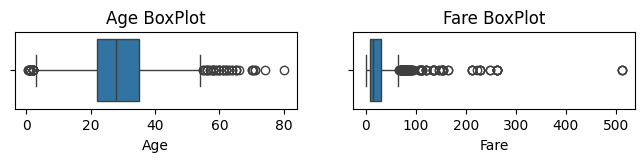

In [19]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient="h")
    plt.title(f"{col} BoxPlot")
    
    

In [20]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    Lower_Fence = Q1 - 1.5 * IQR
    Upper_Fence = Q3 + 1.5 * IQR
    
    Lower_Outliers = df[df[col]<Lower_Fence][col].values
    Upper_Outliers = df[df[col]>Upper_Fence][col].values
    df[col].replace(Lower_Outliers,Lower_Fence,inplace=True)
    df[col].replace(Upper_Outliers,Upper_Fence,inplace=True)

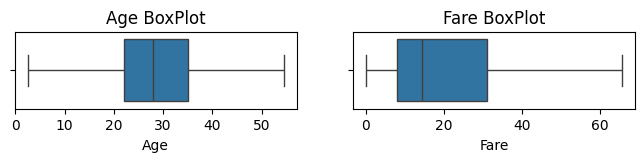

In [21]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.boxplot(df[col],orient="h")
    plt.title(f"{col} BoxPlot")
    
    

### Remove Duplicated

In [22]:
df.duplicated().sum()

np.int64(129)

In [23]:
df.drop_duplicates(inplace=True)

### Visualization

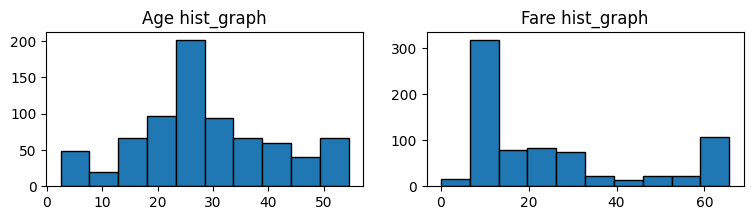

In [24]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    plt.hist(df[col],edgecolor= "black")
    plt.title(f"{col} hist_graph")
plt.show()

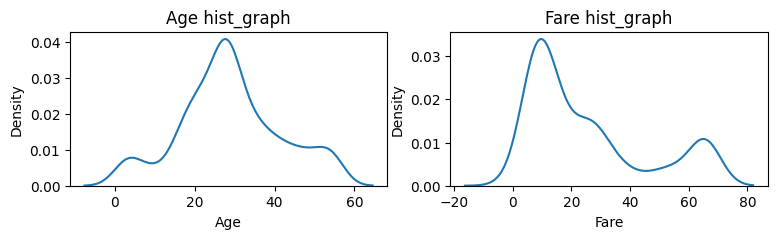

In [25]:
num_cols = df.select_dtypes("number").columns
plt.figure(figsize=(9,2))
for i , col in enumerate(num_cols):
    plt.subplot(1,2,i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

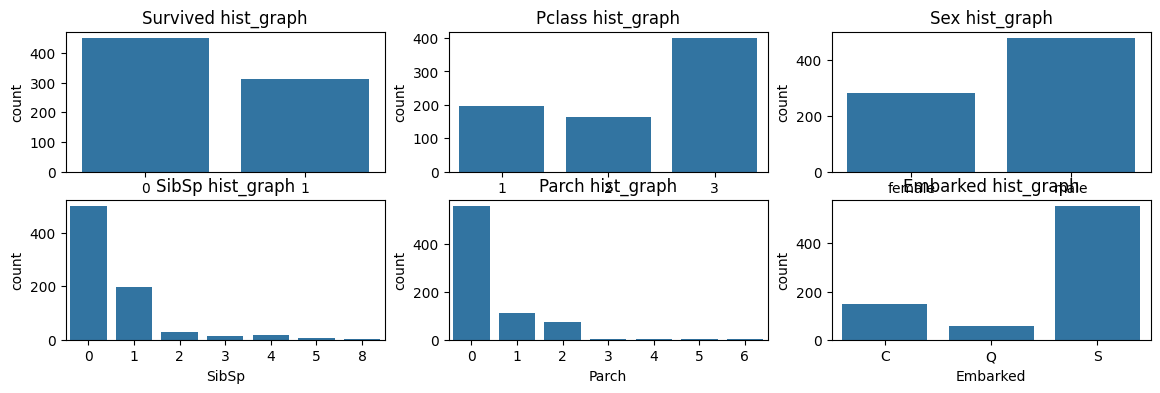

In [26]:
cat_cols = df.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x = col , data = df)
    plt.title(f"{col} hist_graph")
plt.show()

In [27]:

unique = df["Pclass"].value_counts()
count = unique.values

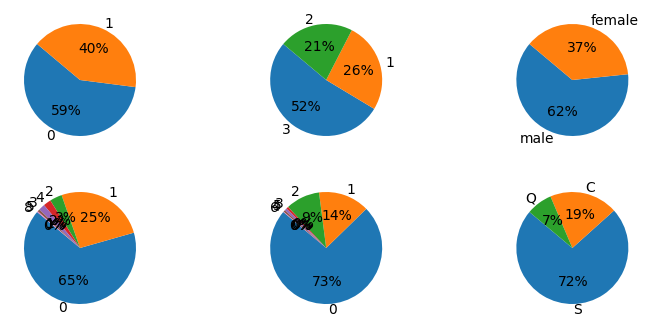

In [28]:
cat_cols = df.select_dtypes('category').columns
plt.figure(figsize=(9,4))
for i , col in enumerate(cat_cols):
    plt.subplot(2,3,i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories = unique.index
    plt.pie(count, labels=categories, startangle=140, autopct='%1.1d%%')

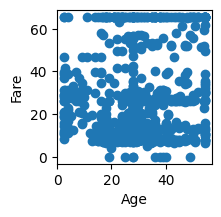

In [29]:
plt.figure(figsize=(2,2))
plt.scatter(df["Age"],df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

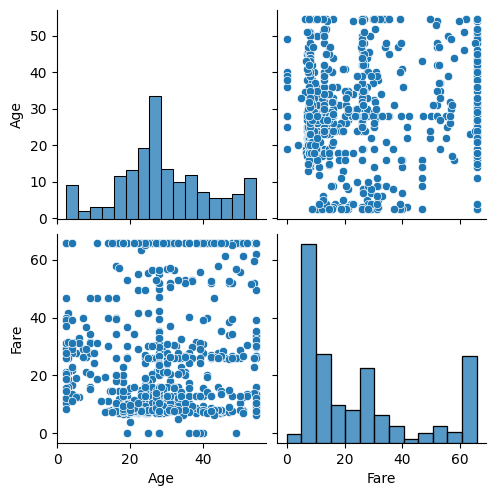

In [30]:
sns.pairplot(df)

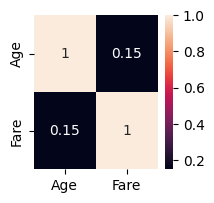

In [31]:
corr = df[num_cols].corr()
plt.figure(figsize=(2,2))
sns.heatmap(corr,annot=True)
plt.show()

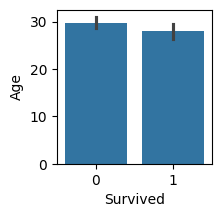

In [32]:
plt.figure(figsize=(2,2))
sns.barplot(x = "Survived", y = "Age" , data = df)
plt.show()

<Axes: xlabel='Sex', ylabel='Survived'>

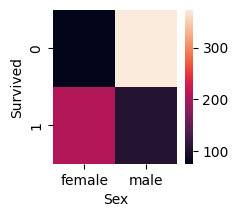

In [33]:
plt.figure(figsize=(2,2))
agg = df.pivot_table(index="Survived",columns="Sex",values="Age",aggfunc=len)
sns.heatmap(agg)


## Data Splitting

In [ ]:
x = df.drop("Survived",axis=1)
y = df[["Survived"]]

In [37]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,65.6563,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


### Normalization

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = x.select_dtypes("number").columns
x[num_cols] = scaler.fit_transform(x[num_cols])
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,0.375000,1,0,0.110424,S
1,1,female,0.682692,1,0,1.000000,C
2,3,female,0.451923,0,0,0.120704,S
3,1,female,0.625000,1,0,0.808757,S
4,3,male,0.625000,0,0,0.122608,S
...,...,...,...,...,...,...,...
885,3,female,0.701923,0,5,0.443598,Q
887,1,female,0.317308,0,0,0.456925,S
888,3,female,0.490385,1,2,0.357163,S
889,1,male,0.451923,0,0,0.456925,C


### Encoding

In [ ]:
str_cols = ["Sex","Embarked"]

['Sex', 'Embarked']

In [44]:
from category_encoders import OneHotEncoder

encoder = OneHotEncoder(cols=str_cols,drop_invariant=True)
x = encoder.fit_transform(x)
x

,Pclass,Sex_1,Sex_2,Age,SibSp,Parch,Fare,Embarked_1,Embarked_2,Embarked_3
0,3,1,0,0.375000,1,0,0.110424,1,0,0
1,1,0,1,0.682692,1,0,1.000000,0,1,0
2,3,0,1,0.451923,0,0,0.120704,1,0,0
3,1,0,1,0.625000,1,0,0.808757,1,0,0
4,3,1,0,0.625000,0,0,0.122608,1,0,0
...,...,...,...,...,...,...,...,...,...,...
885,3,0,1,0.701923,0,5,0.443598,0,0,1
887,1,0,1,0.317308,0,0,0.456925,1,0,0
888,3,0,1,0.490385,1,2,0.357163,1,0,0
889,1,1,0,0.451923,0,0,0.456925,0,1,0
